<a href="https://colab.research.google.com/github/OgunbanjoT/fashion-mnist-classification/blob/main/AI_Assignment12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import classification_report, confusion_matrix

# Load the Fashion MNIST dataset
fashion_mnist = keras.datasets.fashion_mnist
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist.load_data()

# Class names for mapping integers to text labels
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

print(f"Training data shape: {X_train_full.shape}")
print(f"Test data shape: {X_test.shape}")

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 28, 28)
Test data shape: (10000, 28, 28)


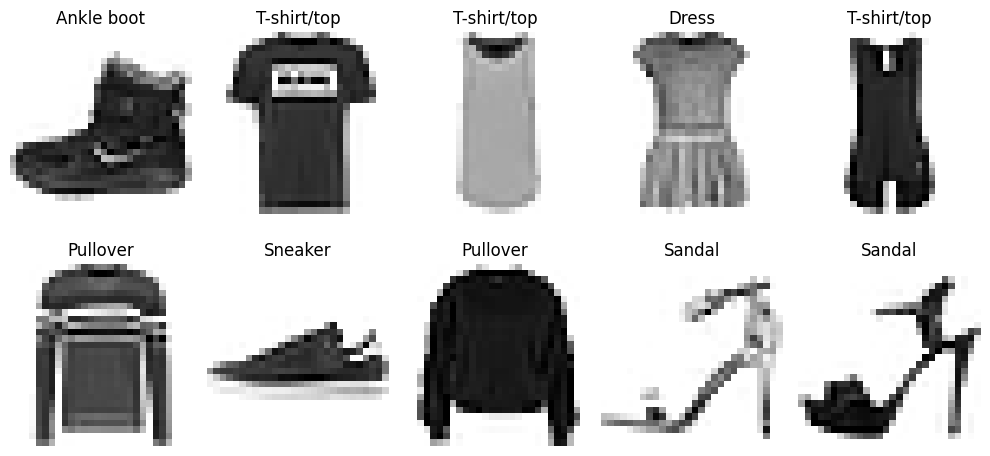

In [2]:
# Visualize the first 10 images from the dataset
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train_full[i], cmap="binary")
    plt.title(class_names[y_train_full[i]])
    plt.axis('off')
plt.tight_layout()
plt.show()

In [3]:
# Preprocessing (Normalization & Validation Split)
# Scale pixel values to a range of 0 to 1 by dividing by 255.0
X_train_full = X_train_full / 255.0
X_test = X_test / 255.0

# Create a validation set (first 5,000 images) and training set (remaining 55,000)
X_valid, X_train = X_train_full[:5000], X_train_full[5000:]
y_valid, y_train = y_train_full[:5000], y_train_full[5000:]

In [4]:
# Build and Compile the Model
# Construct a simple feedforward neural network (Multilayer Perceptron)
model = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]), # Flattens the 2D image into a 1D array of 784 pixels
    keras.layers.Dense(300, activation="relu"),   # Hidden layer 1 with ReLU
    keras.layers.Dense(100, activation="relu"),   # Hidden layer 2 with ReLU
    keras.layers.Dense(10, activation="softmax")   # Output layer with Softmax for 10 classes
])

# Compile the model
model.compile(loss="sparse_categorical_crossentropy",
              optimizer="adam",
              metrics=["accuracy"])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
# Train the Model
# Train for 15 epochs with a batch size of 32
history = model.fit(X_train, y_train, epochs=15, batch_size=32,
                    validation_data=(X_valid, y_valid))

Epoch 1/15
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.8257 - loss: 0.4869 - val_accuracy: 0.8664 - val_loss: 0.3754
Epoch 2/15
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8650 - loss: 0.3658 - val_accuracy: 0.8728 - val_loss: 0.3462
Epoch 3/15
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8799 - loss: 0.3291 - val_accuracy: 0.8904 - val_loss: 0.3123
Epoch 4/15
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8872 - loss: 0.3034 - val_accuracy: 0.8904 - val_loss: 0.2955
Epoch 5/15
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - accuracy: 0.8951 - loss: 0.2859 - val_accuracy: 0.8768 - val_loss: 0.3255
Epoch 6/15
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8987 - loss: 0.2693 - val_accuracy: 0.8890 - val_loss: 0.2973
Epoch 7/15
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9037 - loss: 0.2549 - val_accuracy: 0.8924 - val_loss: 0.2996
Epoch 8/15
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9077 - loss: 0

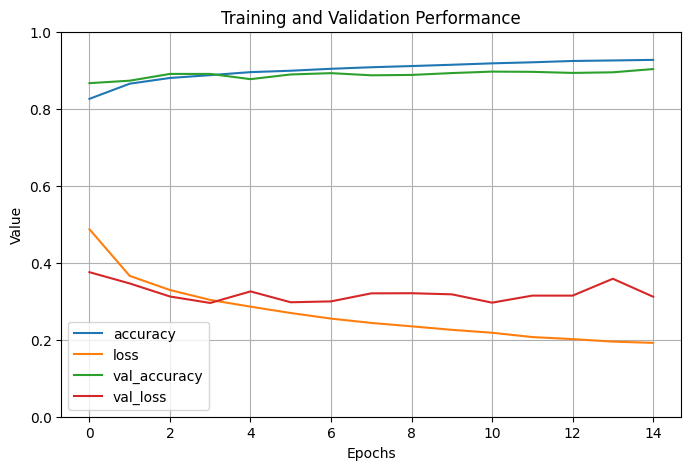

In [6]:
# Evaluate and Plot Results
# Plot Training & Validation Accuracy/Loss
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1)
plt.title("Training and Validation Performance")
plt.xlabel("Epochs")
plt.ylabel("Value")
plt.show()

In [7]:
# Evaluate on the Test Set
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Accuracy: {test_acc:.4f}")


Test Accuracy: 0.8943


In [8]:
# Predict classes for metrics
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [9]:
# Classification Report (Precision, Recall, F1-Score)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=class_names))


Classification Report:

              precision    recall  f1-score   support

 T-shirt/top       0.84      0.87      0.86      1000
     Trouser       0.98      0.98      0.98      1000
    Pullover       0.83      0.79      0.81      1000
       Dress       0.91      0.89      0.90      1000
        Coat       0.75      0.88      0.81      1000
      Sandal       0.99      0.95      0.97      1000
       Shirt       0.76      0.67      0.71      1000
     Sneaker       0.94      0.97      0.95      1000
         Bag       0.98      0.97      0.98      1000
  Ankle boot       0.96      0.97      0.97      1000

    accuracy                           0.89     10000
   macro avg       0.90      0.89      0.89     10000
weighted avg       0.90      0.89      0.89     10000



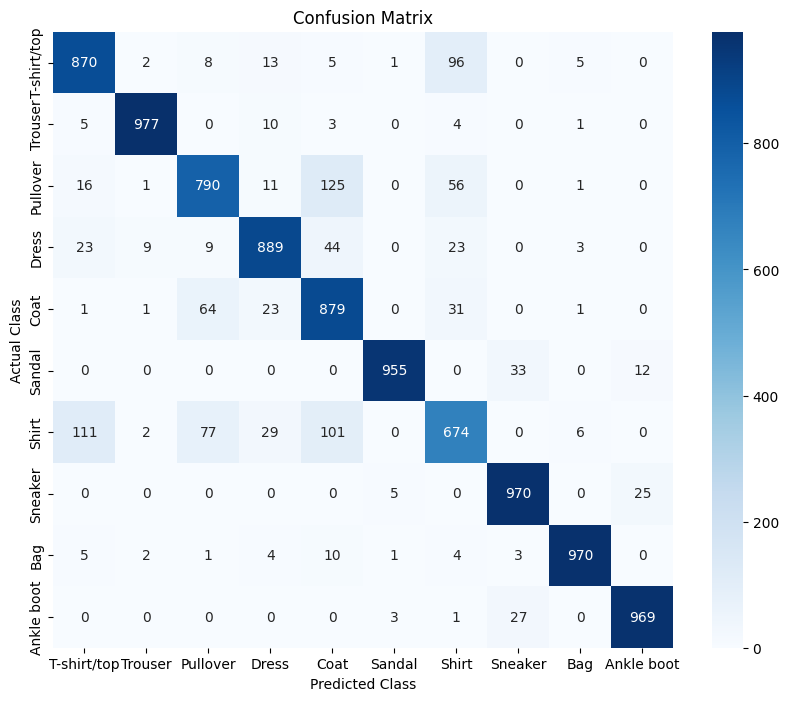

In [10]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('Actual Class')
plt.xlabel('Predicted Class')
plt.show()